# Analiza eksploracyjna danych Heart Disease
## Ćwiczenie 1 - Sieci Neuronowe - Semestr Zimowy 2025

**Cel ćwiczenia:** Wprowadzenie/przypomnienie narzędzi i zapoznanie się z danymi Heart Disease z UCI Machine Learning Repository, które będą wykorzystywane w dalszej części kursu do ewaluacji sieci neuronowych.

**Zbiór danych:** [Heart Disease Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease)

### Plan analizy:
1. **Zbalansowanie klas** - sprawdzenie czy zbiór jest zbalансowany pod względem liczby próbek na klasy
2. **Statystyki cech liczbowych** - średnie i odchylenia standardowe
3. **Rozkłady cech liczbowych** - czy są w przybliżeniu normalne
4. **Rozkłady cech kategorycznych** - czy są w przybliżeniu równomierne
5. **Wartości brakujące** - identyfikacja i strategia zastępowania
6. **Preprocessing** - przekształcenie do macierzy cech liczbowych

## 1. Import bibliotek

Importujemy niezbędne biblioteki do analizy danych i uczenia maszynowego:

In [1]:
# Import podstawowych bibliotek
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Biblioteki scikit-learn do preprocessingu i metryk
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, confusion_matrix

# Ustawienia wyświetlania
plt.style.use('default')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

print("Biblioteki zostały zaimportowane pomyślnie!")
print(f"Wersja pandas: {pd.__version__}")
print(f"Wersja numpy: {np.__version__}")

Biblioteki zostały zaimportowane pomyślnie!
Wersja pandas: 2.3.3
Wersja numpy: 2.3.3


## 2. Wczytanie zbioru danych Heart Disease

Pobieramy i wczytujemy zbiór danych Heart Disease z UCI Machine Learning Repository.

In [ ]:
# Pobieranie danych Heart Disease z UCI
import urllib.request
import os

# URL do danych Heart Disease (Cleveland dataset)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Nazwy kolumn zgodnie z dokumentacją UCI
column_names = [
    'age',           # wiek w latach
    'sex',           # płeć (1 = mężczyzna; 0 = kobieta)
    'cp',            # typ bólu w klatce piersiowej (1-4)
    'trestbps',      # ciśnienie krwi w spoczynku (mm Hg)
    'chol',          # cholesterol w mg/dl
    'fbs',           # cukier we krwi na czczo > 120 mg/dl (1 = prawda; 0 = fałsz)
    'restecg',       # wyniki EKG w spoczynku (0-2)
    'thalach',       # maksymalne osiągnięte tętno
    'exang',         # dławica wysiłkowa (1 = tak; 0 = nie)
    'oldpeak',       # depresja ST wywołana wysiłkiem względem spoczynku
    'slope',         # nachylenie segmentu ST podczas maksymalnego wysiłku (1-3)
    'ca',            # liczba głównych naczyń (0-3) kolorowanych przez fluoroskopię
    'thal',          # 3 = normalny; 6 = defekt stały; 7 = defekt odwracalny
    'target'         # diagnoza choroby serca (0 = brak, 1-4 = obecność)
]

try:
    # Pobieranie danych
    print("Pobieranie danych z UCI Repository...")
    data = pd.read_csv(url, names=column_names, na_values='?')
    print("Dane zostały pomyślnie pobrane!")

    # Podstawowe informacje o zbiorze
    print(f"\nRozmiar zbioru danych: {data.shape}")
    print(f"Liczba próbek: {data.shape[0]}")
    print(f"Liczba cech: {data.shape[1]-1} (+ 1 kolumna target)")

except Exception as e:
    print(f"Błąd podczas pobierania danych: {e}")
    print("Spróbujemy wczytać dane z lokalnego pliku...")

Pobieranie danych z UCI Repository...
Dane zostały pomyślnie pobrane!

Rozmiar zbioru danych: (303, 14)
Liczba próbek: 303
Liczba cech: 13 (+ 1 kolumna target)


## 3. Przegląd struktury danych

Sprawdzmy podstawowe informacje o zbiorze danych oraz wyświetlmy pierwsze wiersze.

In [3]:
# Podstawowe informacje o danych
print("=== PODSTAWOWE INFORMACJE O ZBIORZE ===")
print(f"Kształt danych: {data.shape}")
print(f"Typy danych:")
print(data.dtypes)
print()

# Pierwsze 10 wierszy
print("=== PIERWSZE 10 WIERSZY ===")
display(data.head(10))

# Podstawowe statystyki
print("\n=== PODSTAWOWE STATYSTYKI ===")
display(data.describe())

# Informacje o danych
print("\n=== SZCZEGÓŁOWE INFORMACJE ===")
data.info()

=== PODSTAWOWE INFORMACJE O ZBIORZE ===
Kształt danych: (303, 14)
Typy danych:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

=== PIERWSZE 10 WIERSZY ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
5,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
6,62.0,0.0,4.0,140.0,268.0,0.0,2.0,160.0,0.0,3.6,3.0,2.0,3.0,3
7,57.0,0.0,4.0,120.0,354.0,0.0,0.0,163.0,1.0,0.6,1.0,0.0,3.0,0
8,63.0,1.0,4.0,130.0,254.0,0.0,2.0,147.0,0.0,1.4,2.0,1.0,7.0,2
9,53.0,1.0,4.0,140.0,203.0,1.0,2.0,155.0,1.0,3.1,3.0,0.0,7.0,1



=== PODSTAWOWE STATYSTYKI ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000



=== SZCZEGÓŁOWE INFORMACJE ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    float64
 1   sex       303 non-null    float64
 2   cp        303 non-null    float64
 3   trestbps  303 non-null    float64
 4   chol      303 non-null    float64
 5   fbs       303 non-null    float64
 6   restecg   303 non-null    float64
 7   thalach   303 non-null    float64
 8   exang     303 non-null    float64
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    float64
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(13), int64(1)
memory usage: 33.3 KB


## 4. Analiza zbalansowania klas

Sprawdzamy czy zbiór jest zbalansowany pod względem liczby próbek na klasy.

=== ROZKŁAD ORYGINALNEJ ZMIENNEJ TARGET ===
target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64
Procenty:
target
0    54.13
1    18.15
2    11.88
3    11.55
4     4.29
Name: count, dtype: float64

=== ROZKŁAD BINARNEJ ZMIENNEJ TARGET ===
Brak choroby serca (0): 164 (54.1%)
Choroba serca (1): 139 (45.9%)


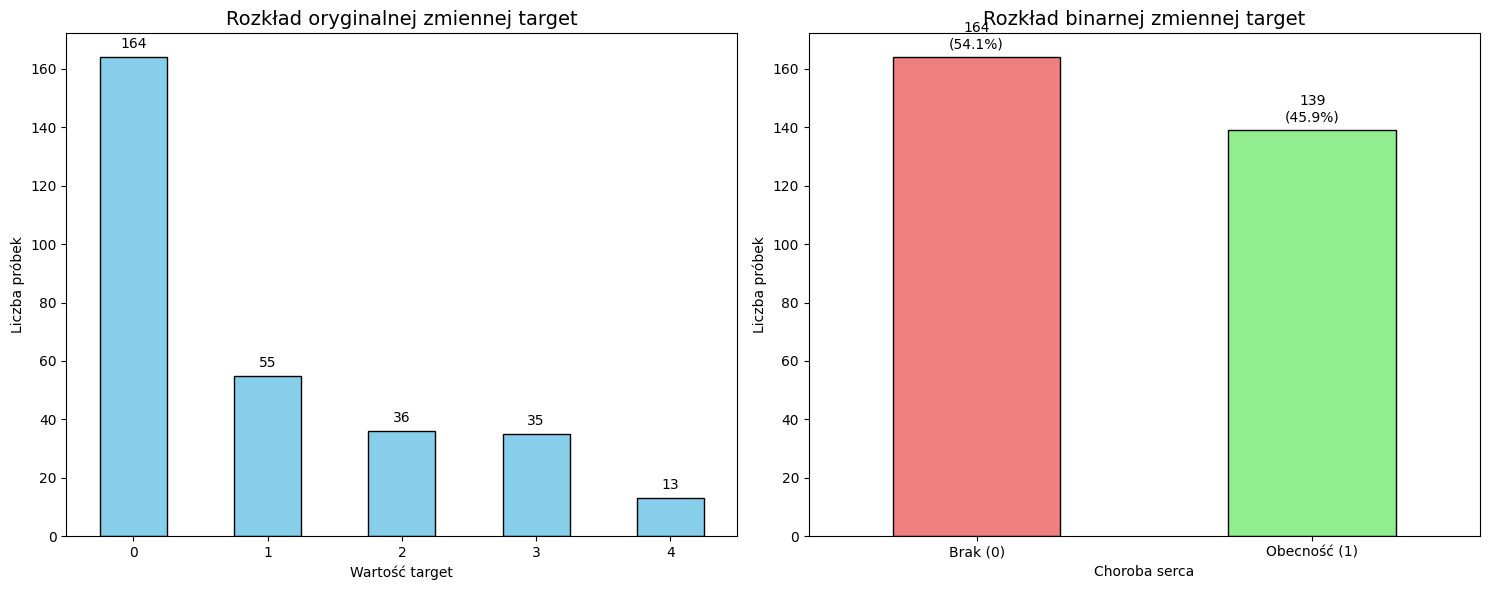


=== OCENA ZBALANSOWANIA ===
Stosunek mniejszej klasy do większej: 0.848
✅ Zbiór jest dobrze zbalansowany


In [4]:
# Przekształcamy target na zmienną binarną (0 = brak choroby, 1 = choroba)
# Oryginalne wartości: 0 = brak, 1-4 = różne stopnie choroby
data['target_binary'] = (data['target'] > 0).astype(int)

# Analiza rozkładu klas
print("=== ROZKŁAD ORYGINALNEJ ZMIENNEJ TARGET ===")
target_counts = data['target'].value_counts().sort_index()
print(target_counts)
print(f"Procenty:")
print((target_counts / len(data) * 100).round(2))

print("\n=== ROZKŁAD BINARNEJ ZMIENNEJ TARGET ===")
binary_counts = data['target_binary'].value_counts().sort_index()
print(f"Brak choroby serca (0): {binary_counts[0]} ({binary_counts[0]/len(data)*100:.1f}%)")
print(f"Choroba serca (1): {binary_counts[1]} ({binary_counts[1]/len(data)*100:.1f}%)")

# Wizualizacja rozkładu klas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Wykres 1: Oryginalne klasy target
target_counts.plot(kind='bar', ax=ax1, color='skyblue', edgecolor='black')
ax1.set_title('Rozkład oryginalnej zmiennej target', fontsize=14)
ax1.set_xlabel('Wartość target')
ax1.set_ylabel('Liczba próbek')
ax1.tick_params(axis='x', rotation=0)

# Dodawanie etykiet na słupki
for i, v in enumerate(target_counts):
    ax1.text(i, v + 2, str(v), ha='center', va='bottom')

# Wykres 2: Binarne klasy
binary_counts.plot(kind='bar', ax=ax2, color=['lightcoral', 'lightgreen'], edgecolor='black')
ax2.set_title('Rozkład binarnej zmiennej target', fontsize=14)
ax2.set_xlabel('Choroba serca')
ax2.set_ylabel('Liczba próbek')
ax2.set_xticklabels(['Brak (0)', 'Obecność (1)'], rotation=0)

# Dodawanie etykiet na słupki
for i, v in enumerate(binary_counts):
    ax2.text(i, v + 2, f'{v}\n({v/len(data)*100:.1f}%)', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# Ocena zbalansowania
ratio = min(binary_counts) / max(binary_counts)
print(f"\n=== OCENA ZBALANSOWANIA ===")
print(f"Stosunek mniejszej klasy do większej: {ratio:.3f}")
if ratio > 0.8:
    print("✅ Zbiór jest dobrze zbalansowany")
elif ratio > 0.6:
    print("⚠️ Zbiór jest umiarkowanie zbalansowany")
else:
    print("❌ Zbiór jest niezbalansowany")

## 5. Analiza statystyczna cech liczbowych

Obliczamy średnie i odchylenia standardowe dla cech liczbowych.

=== CECHY LICZBOWE ===
Cechy liczbowe: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Cechy kategoryczne: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

=== SZCZEGÓŁOWE STATYSTYKI CECH LICZBOWYCH ===


,age,trestbps,chol,thalach,oldpeak
count,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.438944,131.689769,246.693069,149.607261,1.039604
std,9.038662,17.599748,51.776918,22.875003,1.161075
min,29.000000,94.000000,126.000000,71.000000,0.000000
25%,48.000000,120.000000,211.000000,133.500000,0.000000
50%,56.000000,130.000000,241.000000,153.000000,0.800000
75%,61.000000,140.000000,275.000000,166.000000,1.600000
max,77.000000,200.000000,564.000000,202.000000,6.200000



=== ŚREDNIE I ODCHYLENIA STANDARDOWE ===


,Cecha,Średnia,Odchylenie std,Mediana,Min,Max
0,age,54.44,9.04,56.0,29.0,77.0
1,trestbps,131.69,17.60,130.0,94.0,200.0
2,chol,246.69,51.78,241.0,126.0,564.0
3,thalach,149.61,22.88,153.0,71.0,202.0
4,oldpeak,1.04,1.16,0.8,0.0,6.2



=== MACIERZ KORELACJI CECH LICZBOWYCH ===


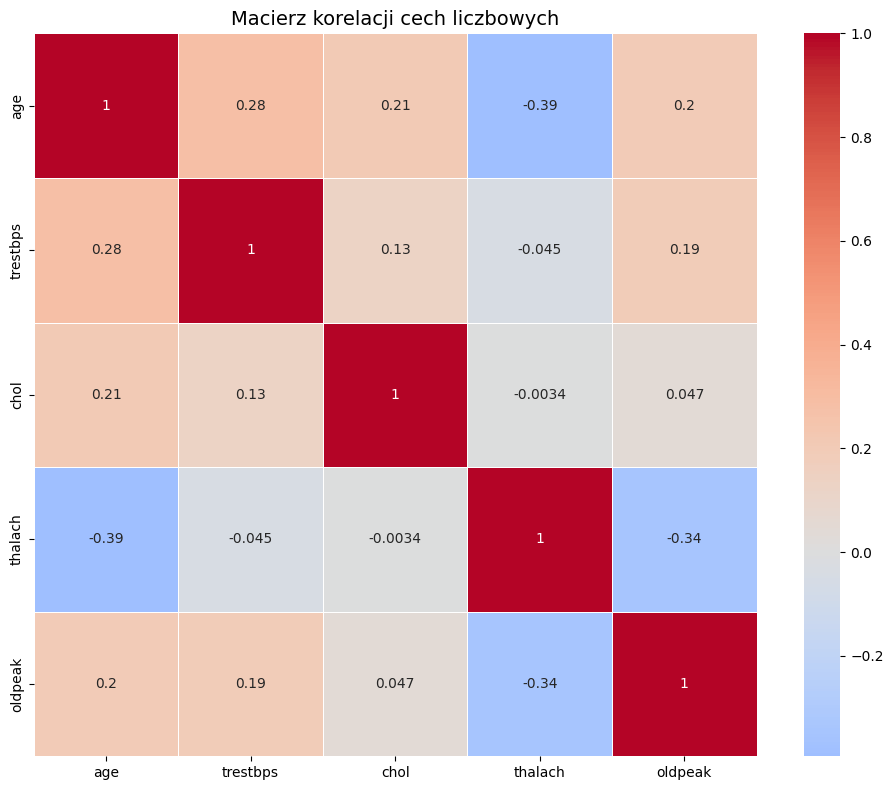


=== NAJSILNIEJSZE KORELACJE ===
age - thalach: -0.394
thalach - oldpeak: -0.343
age - trestbps: 0.285
age - chol: 0.209
age - oldpeak: 0.204


In [5]:
# Identyfikacja cech liczbowych i kategorycznych
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print("=== CECHY LICZBOWE ===")
print(f"Cechy liczbowe: {numerical_features}")
print(f"Cechy kategoryczne: {categorical_features}")

# Szczegółowe statystyki dla cech liczbowych
print("\n=== SZCZEGÓŁOWE STATYSTYKI CECH LICZBOWYCH ===")
numerical_stats = data[numerical_features].describe()
display(numerical_stats)

# Tabela ze średnimi i odchyleniami standardowymi
print("\n=== ŚREDNIE I ODCHYLENIA STANDARDOWE ===")
stats_summary = pd.DataFrame({
    'Cecha': numerical_features,
    'Średnia': [data[col].mean() for col in numerical_features],
    'Odchylenie std': [data[col].std() for col in numerical_features],
    'Mediana': [data[col].median() for col in numerical_features],
    'Min': [data[col].min() for col in numerical_features],
    'Max': [data[col].max() for col in numerical_features]
}).round(2)

display(stats_summary)

# Macierz korelacji dla cech liczbowych
print("\n=== MACIERZ KORELACJI CECH LICZBOWYCH ===")
correlation_matrix = data[numerical_features].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Macierz korelacji cech liczbowych', fontsize=14)
plt.tight_layout()
plt.show()

# Najsilniejsze korelacje
print("\n=== NAJSILNIEJSZE KORELACJE ===")
# Tworzymy płaską listę korelacji (bez diagonali)
corr_pairs = []
for i in range(len(numerical_features)):
    for j in range(i+1, len(numerical_features)):
        corr_val = correlation_matrix.iloc[i, j]
        corr_pairs.append((numerical_features[i], numerical_features[j], abs(corr_val), corr_val))

# Sortujemy po wartości bezwzględnej korelacji
corr_pairs.sort(key=lambda x: x[2], reverse=True)

for feat1, feat2, abs_corr, corr in corr_pairs[:5]:
    print(f"{feat1} - {feat2}: {corr:.3f}")

## 6. Analiza rozkładów cech liczbowych

Sprawdzamy czy rozkłady cech liczbowych są w przybliżeniu normalne.

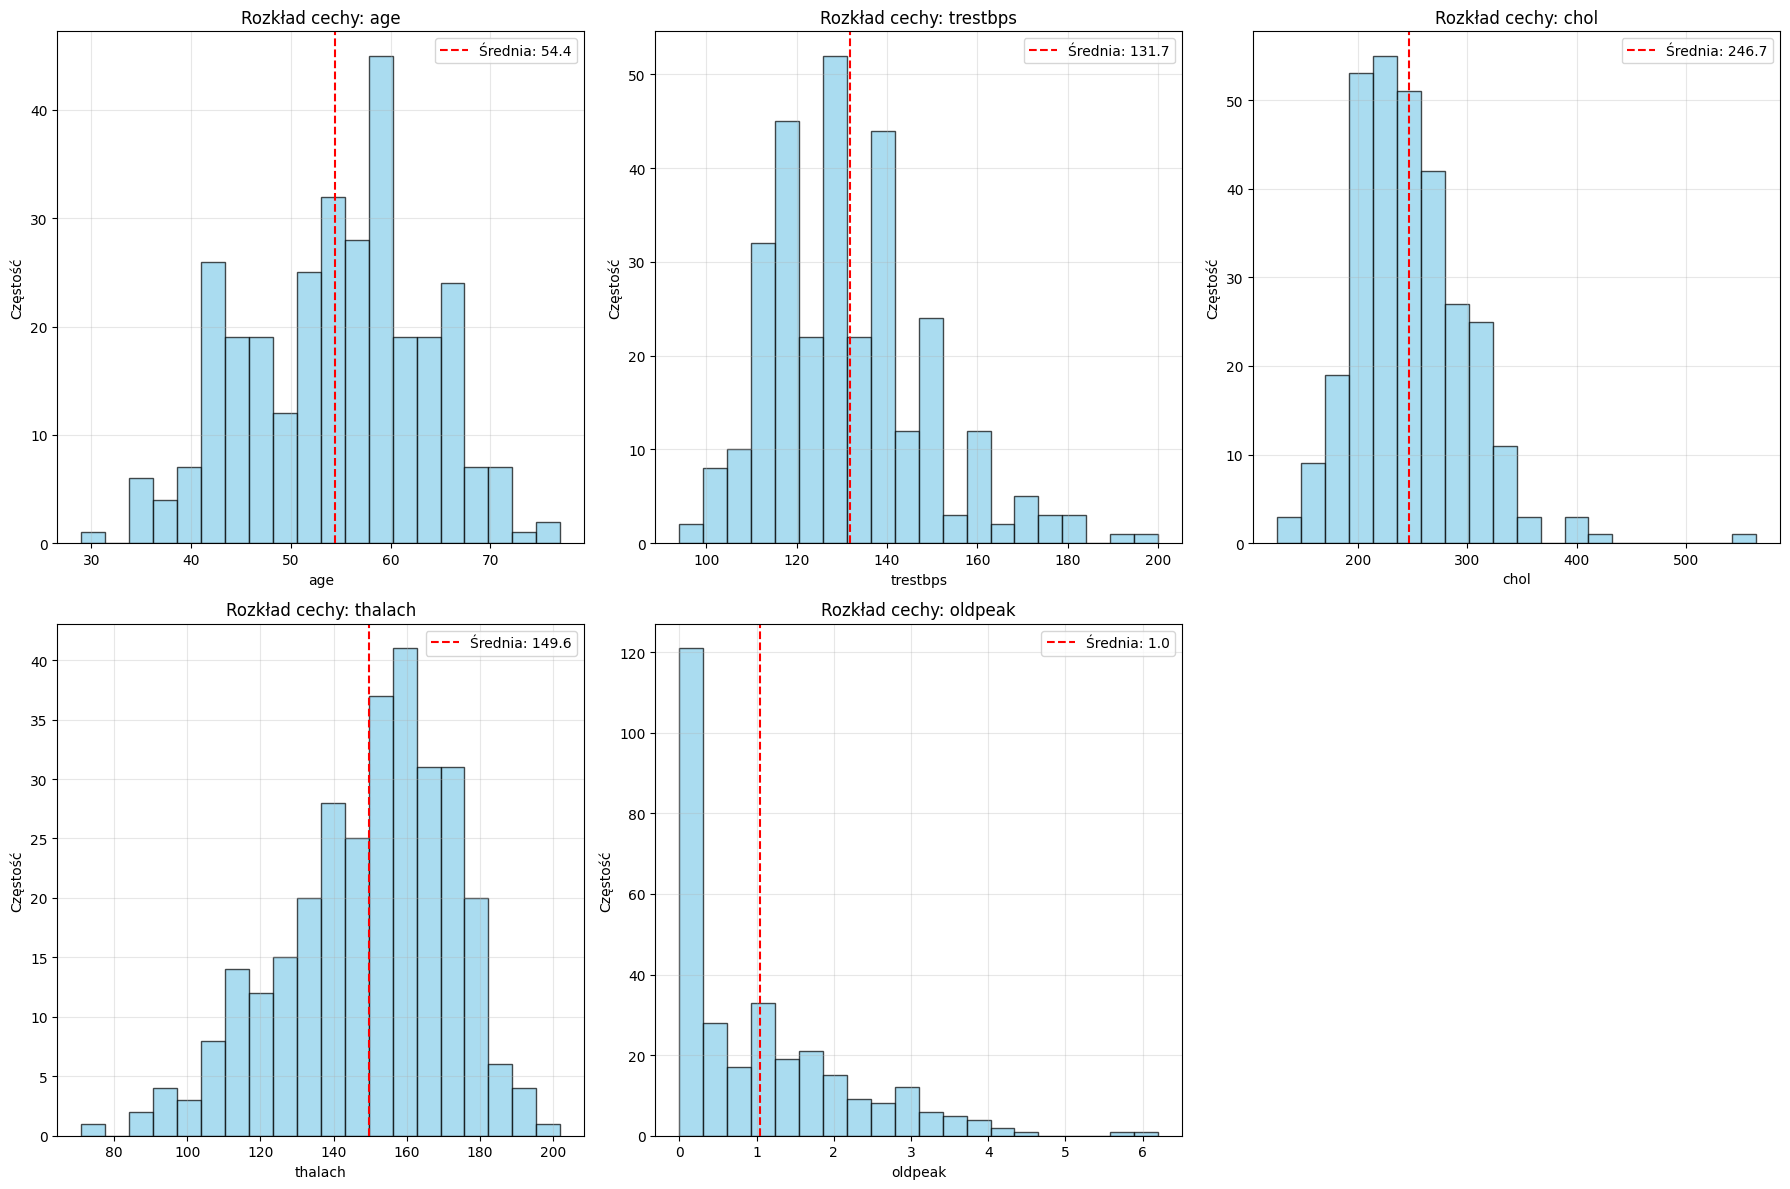

=== TESTY NORMALNOŚCI ROZKŁADÓW (TEST SHAPIRO-WILKA) ===
p-value > 0.05 = rozkład normalny
p-value < 0.05 = rozkład nie jest normalny
------------------------------------------------------------
age          | p-value: 0.006069 | Normalny: NIE
trestbps     | p-value: 0.000002 | Normalny: NIE
chol         | p-value: 0.000000 | Normalny: NIE
thalach      | p-value: 0.000070 | Normalny: NIE
oldpeak      | p-value: 0.000000 | Normalny: NIE


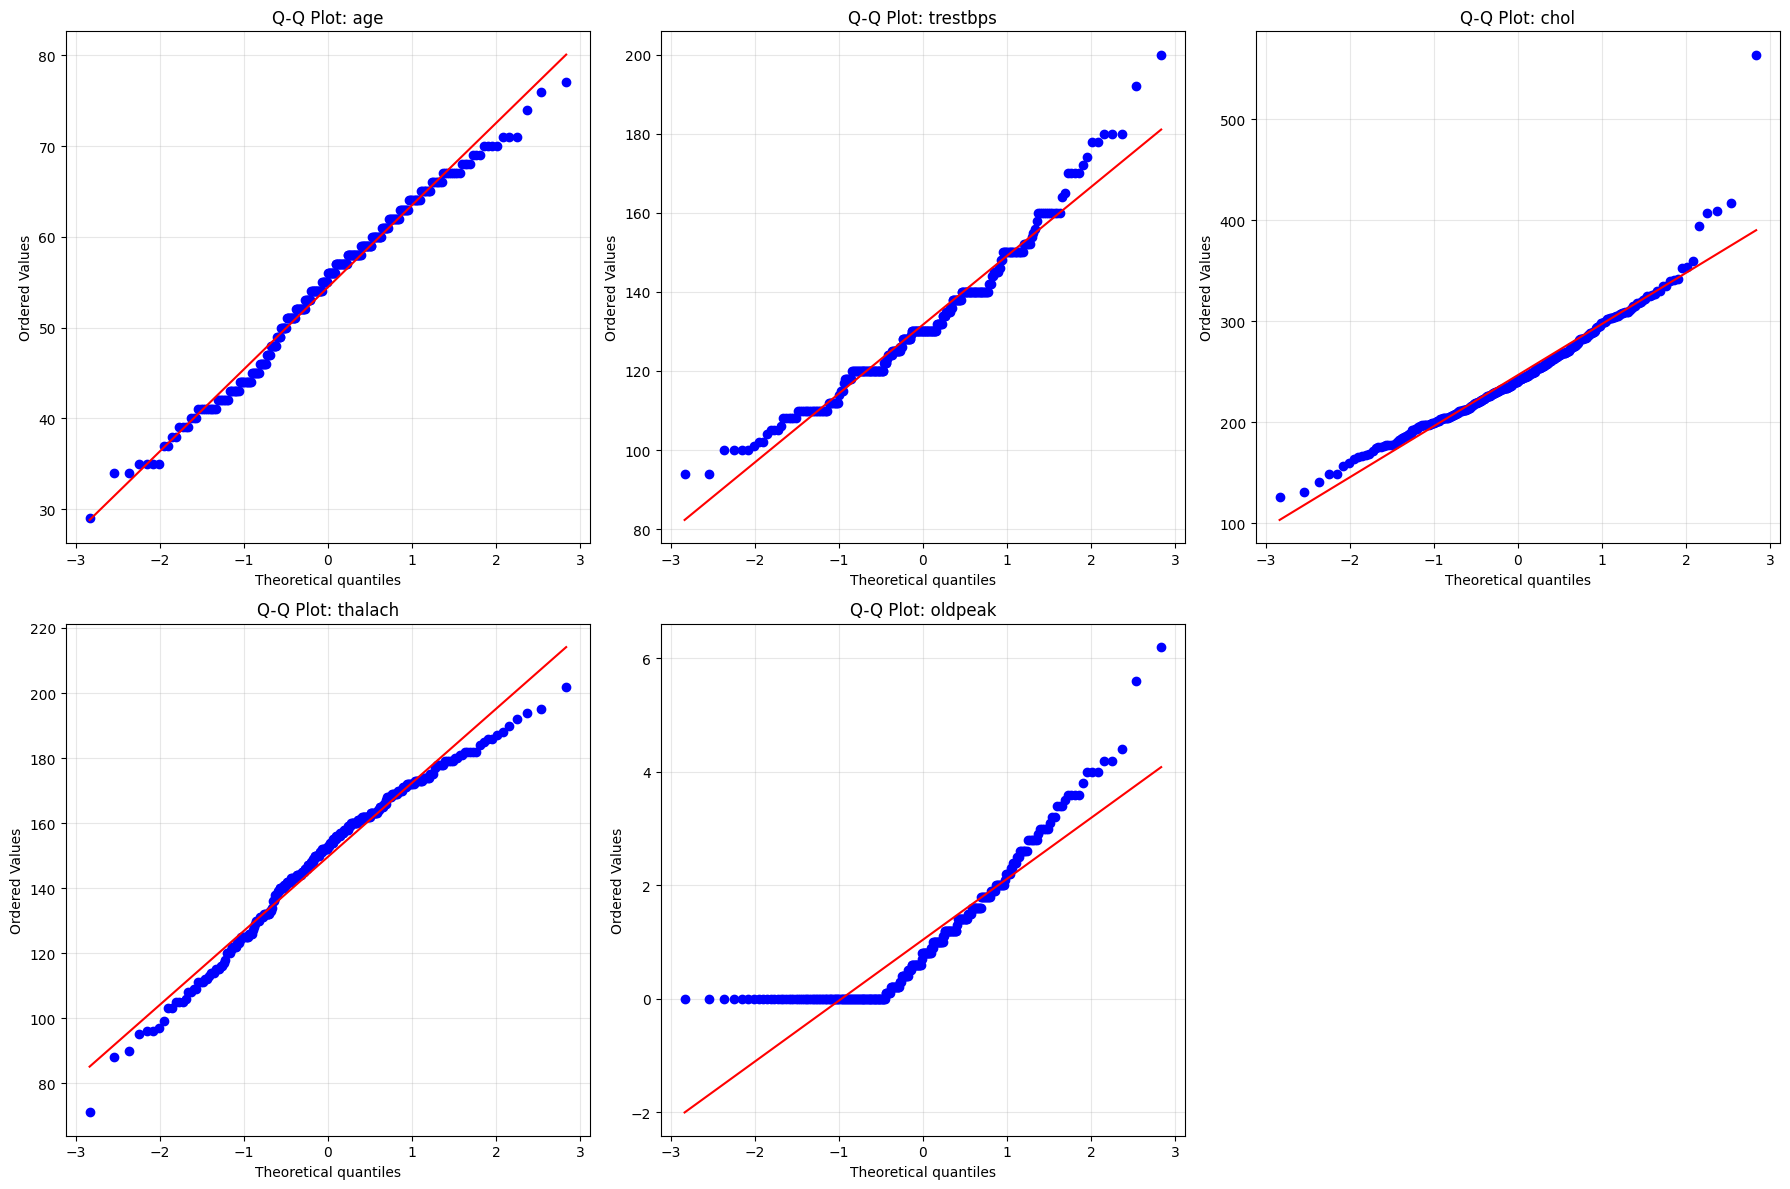


=== PODSUMOWANIE NORMALNOŚCI ROZKŁADÓW ===
Liczba cech z rozkładem normalnym: 0/5
Procent cech z rozkładem normalnym: 0.0%
❌ Większość cech nie ma rozkładu normalnego - może być potrzebna transformacja


In [6]:
# Histogramy cech liczbowych
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(numerical_features):
    # Histogram
    axes[i].hist(data[feature].dropna(), bins=20, alpha=0.7, color='skyblue', edgecolor='black')
    axes[i].set_title(f'Rozkład cechy: {feature}', fontsize=12)
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Częstość')
    axes[i].grid(True, alpha=0.3)

    # Dodawanie linii średniej
    mean_val = data[feature].mean()
    axes[i].axvline(mean_val, color='red', linestyle='--', label=f'Średnia: {mean_val:.1f}')
    axes[i].legend()

# Usuwamy pusty subplot
axes[-1].remove()
plt.tight_layout()
plt.show()

# Testy normalności
print("=== TESTY NORMALNOŚCI ROZKŁADÓW (TEST SHAPIRO-WILKA) ===")
print("p-value > 0.05 = rozkład normalny")
print("p-value < 0.05 = rozkład nie jest normalny")
print("-" * 60)

normality_results = []
for feature in numerical_features:
    # Usuwamy brakujące wartości
    clean_data = data[feature].dropna()

    # Test Shapiro-Wilka (jeśli próbka < 5000)
    if len(clean_data) < 5000:
        stat, p_value = stats.shapiro(clean_data)
        test_name = "Shapiro-Wilk"
    else:
        # Dla większych próbek używamy testu D'Agostino
        stat, p_value = stats.normaltest(clean_data)
        test_name = "D'Agostino"

    is_normal = "TAK" if p_value > 0.05 else "NIE"
    print(f"{feature:12} | p-value: {p_value:.6f} | Normalny: {is_normal:3}")

    normality_results.append({
        'Cecha': feature,
        'Test': test_name,
        'p-value': p_value,
        'Normalny': is_normal
    })

# Q-Q plots dla sprawdzenia normalności
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, feature in enumerate(numerical_features):
    clean_data = data[feature].dropna()
    stats.probplot(clean_data, dist="norm", plot=axes[i])
    axes[i].set_title(f'Q-Q Plot: {feature}', fontsize=12)
    axes[i].grid(True, alpha=0.3)

axes[-1].remove()
plt.tight_layout()
plt.show()

# Podsumowanie normalności
print("\n=== PODSUMOWANIE NORMALNOŚCI ROZKŁADÓW ===")
normal_count = sum(1 for result in normality_results if result['Normalny'] == 'TAK')
print(f"Liczba cech z rozkładem normalnym: {normal_count}/{len(numerical_features)}")
print(f"Procent cech z rozkładem normalnym: {normal_count/len(numerical_features)*100:.1f}%")

if normal_count == len(numerical_features):
    print("✅ Wszystkie cechy liczbowe mają rozkład normalny")
elif normal_count > len(numerical_features) // 2:
    print("⚠️ Większość cech ma rozkład normalny")
else:
    print("❌ Większość cech nie ma rozkładu normalnego - może być potrzebna transformacja")

## 7. Analiza rozkładów cech kategorycznych

Sprawdzamy czy rozkłady cech kategorycznych są w przybliżeniu równomierne.

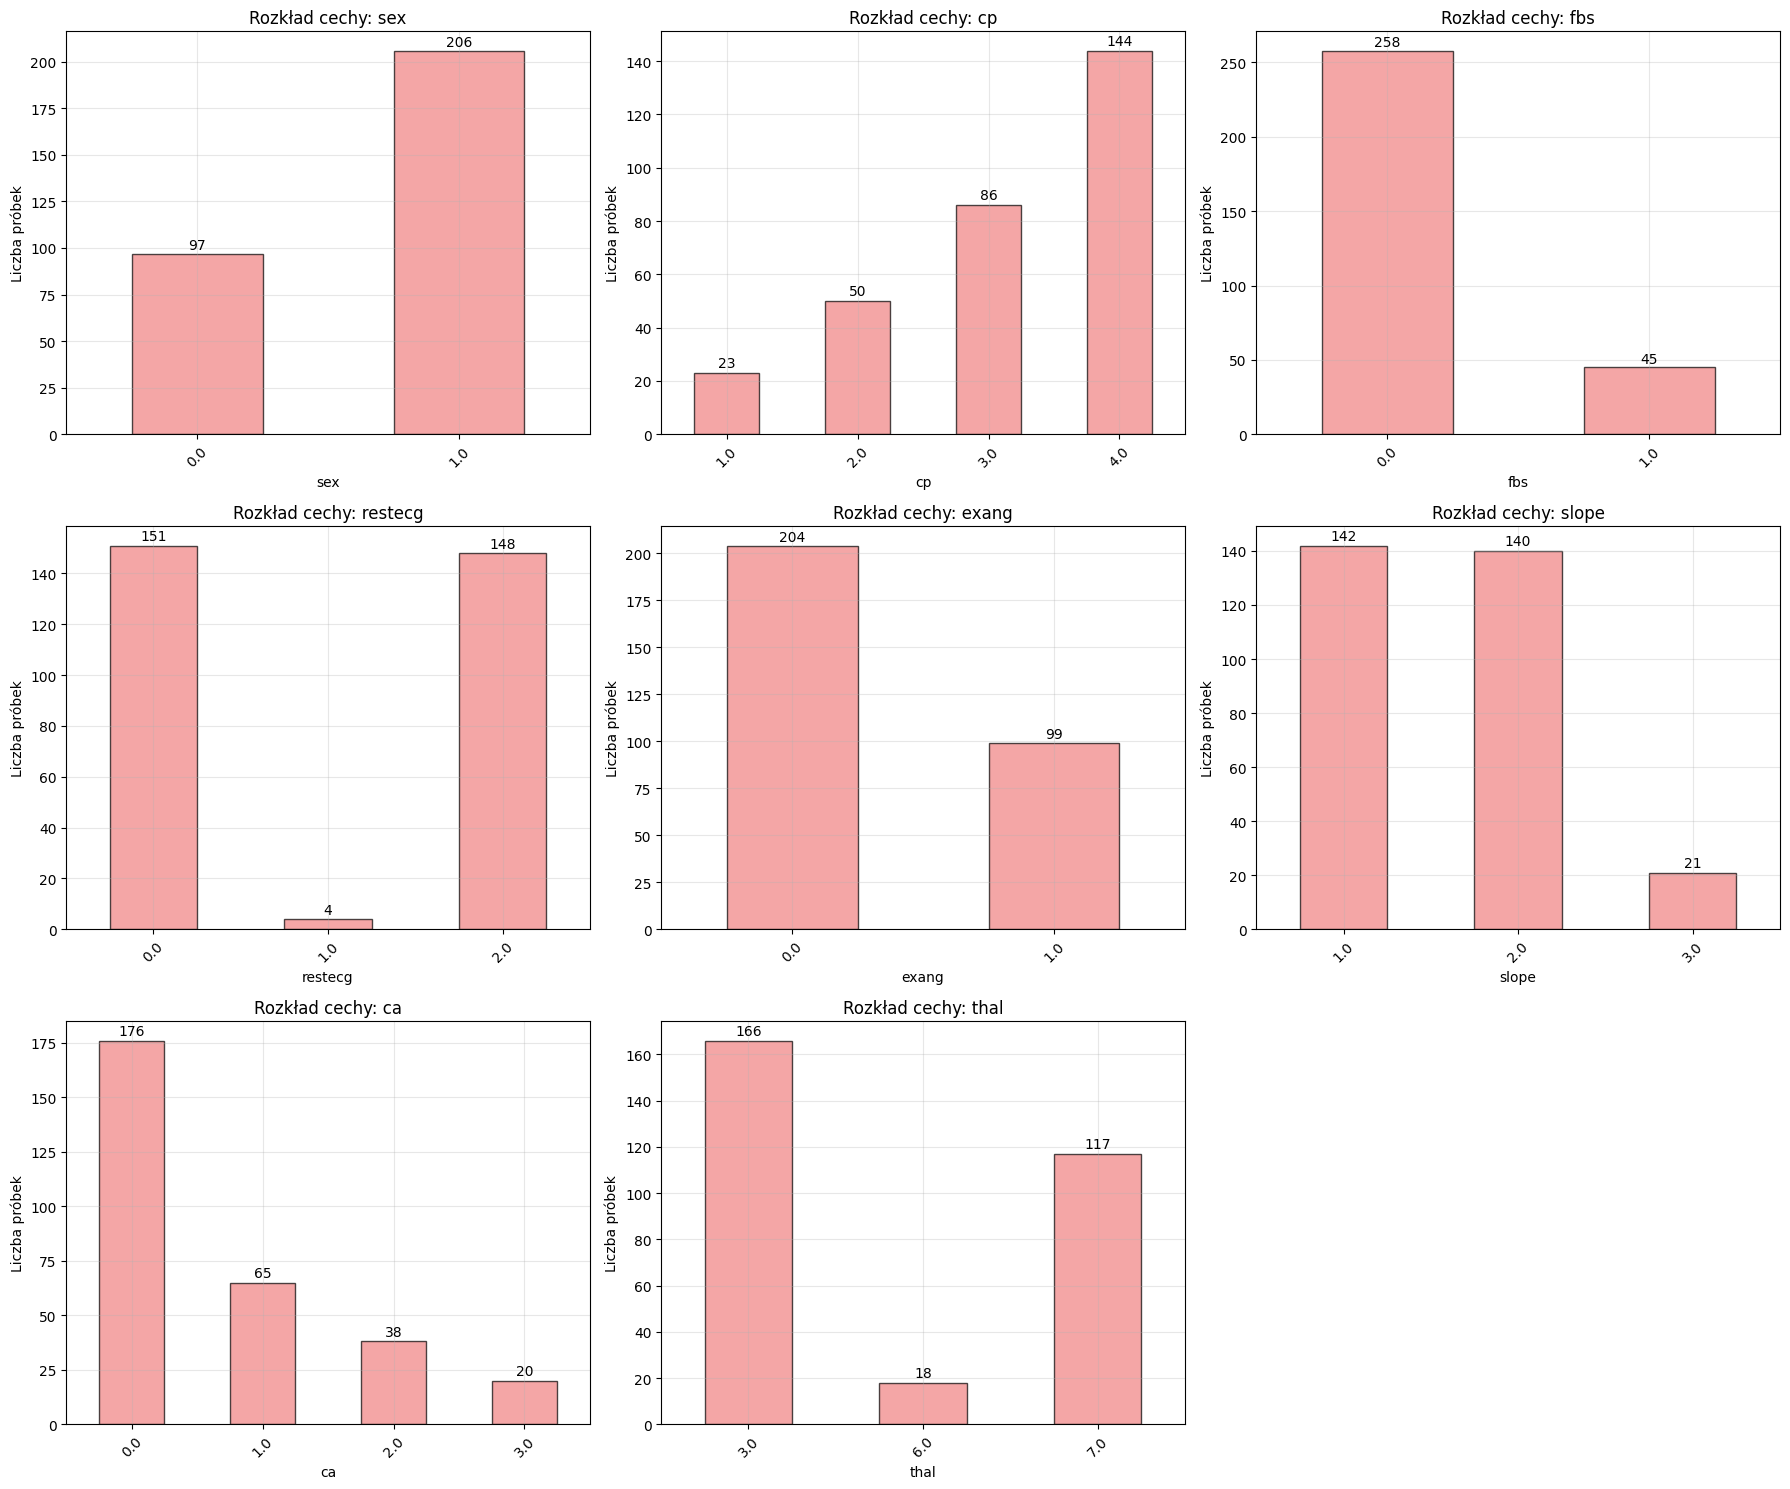

=== SZCZEGÓŁOWA ANALIZA CECH KATEGORYCZNYCH ===
--------------------------------------------------------------------------------

🔍 CECHA: SEX
Liczba kategorii: 2
Rozkład:
  0.0: 97 (32.0%)
  1.0: 206 (68.0%)
Współczynnik zmienności (CV): 0.509
Test chi-kwadrat p-value: 0.000000
❌ Rozkład nie jest równomierny

🔍 CECHA: CP
Liczba kategorii: 4
Rozkład:
  1.0: 23 (7.6%)
  2.0: 50 (16.5%)
  3.0: 86 (28.4%)
  4.0: 144 (47.5%)
Współczynnik zmienności (CV): 0.691
Test chi-kwadrat p-value: 0.000000
❌ Rozkład nie jest równomierny

🔍 CECHA: FBS
Liczba kategorii: 2
Rozkład:
  0.0: 258 (85.1%)
  1.0: 45 (14.9%)
Współczynnik zmienności (CV): 0.994
Test chi-kwadrat p-value: 0.000000
❌ Rozkład nie jest równomierny

🔍 CECHA: RESTECG
Liczba kategorii: 3
Rozkład:
  0.0: 151 (49.8%)
  1.0: 4 (1.3%)
  2.0: 148 (48.8%)
Współczynnik zmienności (CV): 0.832
Test chi-kwadrat p-value: 0.000000
❌ Rozkład nie jest równomierny

🔍 CECHA: EXANG
Liczba kategorii: 2
Rozkład:
  0.0: 204 (67.3%)
  1.0: 99 (32.7%)
Współc

,Cecha,Liczba_kategorii,CV,Chi2_p_value,Równomierny
0,sex,2,0.509,0.0,NIE
1,cp,4,0.691,0.0,NIE
2,fbs,2,0.994,0.0,NIE
3,restecg,3,0.832,0.0,NIE
4,exang,2,0.490,0.0,NIE
5,slope,3,0.686,0.0,NIE
6,ca,4,0.936,0.0,NIE
7,thal,3,0.751,0.0,NIE


In [7]:
# Analiza rozkładów cech kategorycznych
fig, axes = plt.subplots(3, 3, figsize=(18, 15))
axes = axes.ravel()

uniformity_results = []

for i, feature in enumerate(categorical_features):
    # Zliczenie wartości
    value_counts = data[feature].value_counts().sort_index()

    # Wykres słupkowy
    value_counts.plot(kind='bar', ax=axes[i], color='lightcoral', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Rozkład cechy: {feature}', fontsize=12)
    axes[i].set_xlabel(f'{feature}')
    axes[i].set_ylabel('Liczba próbek')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(True, alpha=0.3)

    # Dodawanie etykiet na słupki
    for j, v in enumerate(value_counts):
        axes[i].text(j, v + 1, str(v), ha='center', va='bottom')

    # Ocena równomierności rozkładu
    total_values = len(value_counts)
    expected_freq = len(data[feature].dropna()) / total_values

    # Współczynnik zmienności (CV) - im niższy, tym bardziej równomierny
    cv = value_counts.std() / value_counts.mean()

    # Test chi-kwadrat dla równomierności
    chi2_stat, chi2_p = stats.chisquare(value_counts)

    is_uniform = "TAK" if chi2_p > 0.05 else "NIE"

    uniformity_results.append({
        'Cecha': feature,
        'Liczba_kategorii': total_values,
        'CV': cv,
        'Chi2_p_value': chi2_p,
        'Równomierny': is_uniform
    })

# Usuwamy pusty subplot jeśli jest
if len(categorical_features) < len(axes):
    axes[-1].remove()

plt.tight_layout()
plt.show()

# Szczegółowa analiza każdej cechy kategorycznej
print("=== SZCZEGÓŁOWA ANALIZA CECH KATEGORYCZNYCH ===")
print("-" * 80)

for feature in categorical_features:
    print(f"\n🔍 CECHA: {feature.upper()}")
    value_counts = data[feature].value_counts().sort_index()
    percentages = (value_counts / len(data[feature].dropna()) * 100).round(1)

    print(f"Liczba kategorii: {len(value_counts)}")
    print(f"Rozkład:")
    for cat, count in value_counts.items():
        print(f"  {cat}: {count} ({percentages[cat]}%)")

    # Ocena równomierności
    cv = value_counts.std() / value_counts.mean()
    chi2_stat, chi2_p = stats.chisquare(value_counts)

    print(f"Współczynnik zmienności (CV): {cv:.3f}")
    print(f"Test chi-kwadrat p-value: {chi2_p:.6f}")

    if chi2_p > 0.05:
        print("✅ Rozkład jest równomierny")
    else:
        print("❌ Rozkład nie jest równomierny")

# Podsumowanie równomierności
print("\n" + "="*80)
print("=== PODSUMOWANIE RÓWNOMIERNOŚCI ROZKŁADÓW KATEGORYCZNYCH ===")
uniform_count = sum(1 for result in uniformity_results if result['Równomierny'] == 'TAK')
print(f"Liczba cech z rozkładem równomiernym: {uniform_count}/{len(categorical_features)}")
print(f"Procent cech z rozkładem równomiernym: {uniform_count/len(categorical_features)*100:.1f}%")

# Tabela podsumowująca
uniformity_df = pd.DataFrame(uniformity_results)
print("\nTabela podsumowująca:")
display(uniformity_df.round(3))

## 8. Analiza brakujących wartości i strategia ich zastępowania

Sprawdzamy czy występują brakujące wartości i definiujemy strategię ich zastępowania.

=== ANALIZA BRAKUJĄCYCH WARTOŚCI ===
Cechy z brakującymi wartościami:


,Cecha,Liczba_brakujących,Procent_brakujących
11,ca,4,1.32
12,thal,2,0.66


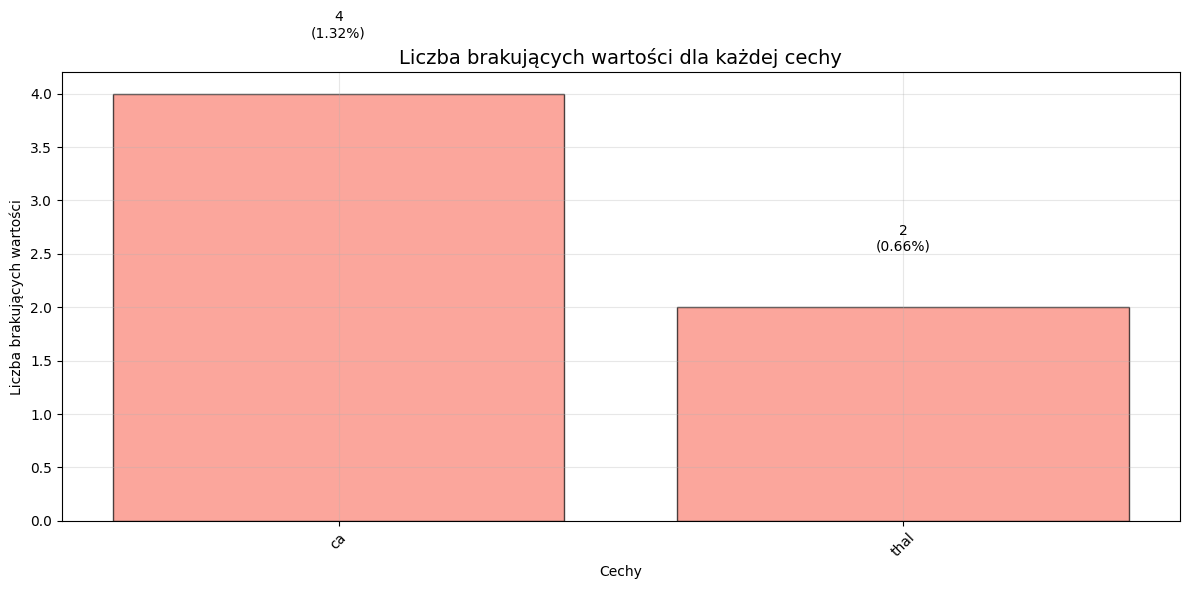

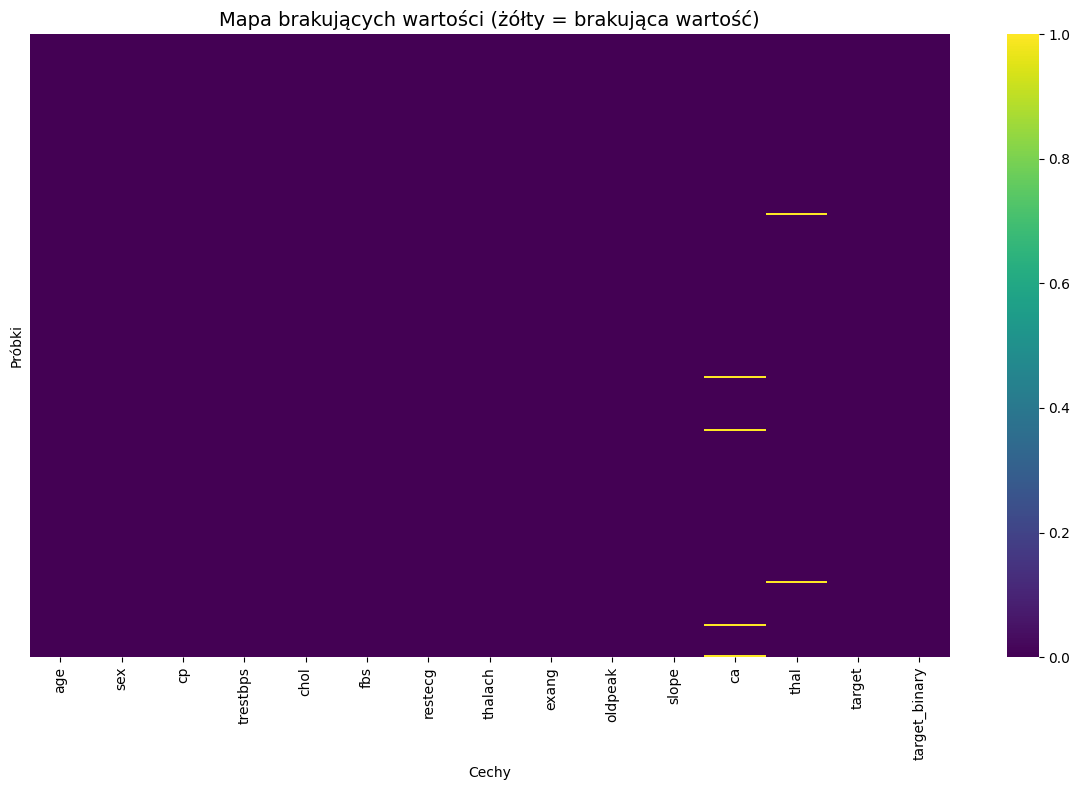


Ogólne statystyki:
Całkowita liczba wartości: 4545
Liczba brakujących wartości: 6
Procent brakujących wartości: 0.13%

=== STRATEGIA ZASTĘPOWANIA BRAKUJĄCYCH WARTOŚCI ===

🔧 PROPONOWANE STRATEGIE:

📌 ca:
   Brakujące: 4 (1.32%)
   Typ: kategoryczna
   Najczęstsza wartość: 0.0
   ✅ Strategia: zastąp najczęstszą wartością (< 5% brakujących)

📌 thal:
   Brakujące: 2 (0.66%)
   Typ: kategoryczna
   Najczęstsza wartość: 3.0
   ✅ Strategia: zastąp najczęstszą wartością (< 5% brakujących)

=== IMPLEMENTACJA STRATEGII ZASTĘPOWANIA ===
✅ ca: zastąpiono 4 wartości najczęstszą (0.0)
✅ thal: zastąpiono 2 wartości najczęstszą (3.0)

📊 WYNIKI:
Brakujące wartości przed: 6
Brakujące wartości po: 0
Usunięto: 6 brakujących wartości


In [8]:
# Analiza brakujących wartości
print("=== ANALIZA BRAKUJĄCYCH WARTOŚCI ===")
missing_values = data.isnull().sum()
missing_percent = (missing_values / len(data) * 100).round(2)

missing_df = pd.DataFrame({
    'Cecha': missing_values.index,
    'Liczba_brakujących': missing_values.values,
    'Procent_brakujących': missing_percent.values
})

# Filtrujemy tylko cechy z brakującymi wartościami
missing_df = missing_df[missing_df['Liczba_brakujących'] > 0].sort_values('Liczba_brakujących', ascending=False)

if len(missing_df) > 0:
    print("Cechy z brakującymi wartościami:")
    display(missing_df)

    # Wizualizacja brakujących wartości
    plt.figure(figsize=(12, 6))
    missing_features = missing_df['Cecha'].tolist()
    missing_counts = missing_df['Liczba_brakujących'].tolist()

    bars = plt.bar(range(len(missing_features)), missing_counts, color='salmon', alpha=0.7, edgecolor='black')
    plt.title('Liczba brakujących wartości dla każdej cechy', fontsize=14)
    plt.xlabel('Cechy')
    plt.ylabel('Liczba brakujących wartości')
    plt.xticks(range(len(missing_features)), missing_features, rotation=45)
    plt.grid(True, alpha=0.3)

    # Dodawanie etykiet na słupki
    for bar, count, percent in zip(bars, missing_counts, missing_df['Procent_brakujących']):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{count}\n({percent}%)', ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

    # Mapa ciepła brakujących wartości
    plt.figure(figsize=(12, 8))
    missing_matrix = data.isnull()
    sns.heatmap(missing_matrix, cbar=True, yticklabels=False, cmap='viridis')
    plt.title('Mapa brakujących wartości (żółty = brakująca wartość)', fontsize=14)
    plt.xlabel('Cechy')
    plt.ylabel('Próbki')
    plt.tight_layout()
    plt.show()

else:
    print("✅ Brak brakujących wartości w zbiorze danych!")

print(f"\nOgólne statystyki:")
print(f"Całkowita liczba wartości: {data.size}")
print(f"Liczba brakujących wartości: {data.isnull().sum().sum()}")
print(f"Procent brakujących wartości: {(data.isnull().sum().sum() / data.size * 100):.2f}%")

# Strategia zastępowania brakujących wartości
print("\n" + "="*60)
print("=== STRATEGIA ZASTĘPOWANIA BRAKUJĄCYCH WARTOŚCI ===")

if len(missing_df) > 0:
    print("\n🔧 PROPONOWANE STRATEGIE:")

    for _, row in missing_df.iterrows():
        feature = row['Cecha']
        missing_count = row['Liczba_brakujących']
        missing_percent = row['Procent_brakujących']

        print(f"\n📌 {feature}:")
        print(f"   Brakujące: {missing_count} ({missing_percent}%)")

        if feature in numerical_features:
            mean_val = data[feature].mean()
            median_val = data[feature].median()
            print(f"   Typ: liczbowa")
            print(f"   Średnia: {mean_val:.2f}, Mediana: {median_val:.2f}")

            if missing_percent < 5:
                print("   ✅ Strategia: zastąp średnią lub medianą (< 5% brakujących)")
            elif missing_percent < 20:
                print("   ⚠️ Strategia: zastąp medianą lub usuń próbki (5-20% brakujących)")
            else:
                print("   ❌ Strategia: rozważ usunięcie cechy (> 20% brakujących)")

        elif feature in categorical_features:
            mode_val = data[feature].mode()
            print(f"   Typ: kategoryczna")
            if len(mode_val) > 0:
                print(f"   Najczęstsza wartość: {mode_val.iloc[0]}")

            if missing_percent < 5:
                print("   ✅ Strategia: zastąp najczęstszą wartością (< 5% brakujących)")
            elif missing_percent < 20:
                print("   ⚠️ Strategia: zastąp najczęstszą wartością lub usuń próbki")
            else:
                print("   ❌ Strategia: rozważ usunięcie cechy (> 20% brakujących)")

    # Implementacja strategii zastępowania
    print("\n" + "="*60)
    print("=== IMPLEMENTACJA STRATEGII ZASTĘPOWANIA ===")

    data_cleaned = data.copy()

    for _, row in missing_df.iterrows():
        feature = row['Cecha']
        missing_percent = row['Procent_brakujących']

        if missing_percent < 20:  # Zastępujemy tylko jeśli < 20% brakujących
            if feature in numerical_features:
                # Dla cech liczbowych używamy mediany (bardziej odporna na wartości odstające)
                median_val = data[feature].median()
                data_cleaned[feature].fillna(median_val, inplace=True)
                print(f"✅ {feature}: zastąpiono {row['Liczba_brakujących']} wartości medianą ({median_val:.2f})")

            elif feature in categorical_features:
                # Dla cech kategorycznych używamy najczęstszej wartości
                mode_val = data[feature].mode().iloc[0] if len(data[feature].mode()) > 0 else 'unknown'
                data_cleaned[feature].fillna(mode_val, inplace=True)
                print(f"✅ {feature}: zastąpiono {row['Liczba_brakujących']} wartości najczęstszą ({mode_val})")
        else:
            print(f"⚠️ {feature}: pozostawiono brakujące wartości (>20% brakujących - rozważ usunięcie cechy)")

    # Sprawdzenie wyników
    remaining_missing = data_cleaned.isnull().sum().sum()
    print(f"\n📊 WYNIKI:")
    print(f"Brakujące wartości przed: {data.isnull().sum().sum()}")
    print(f"Brakujące wartości po: {remaining_missing}")
    print(f"Usunięto: {data.isnull().sum().sum() - remaining_missing} brakujących wartości")

    # Zapisujemy wyczyszczone dane do dalszego użytku
    globals()['data_cleaned'] = data_cleaned

else:
    print("✅ Brak brakujących wartości - żadne działania nie są potrzebne!")
    data_cleaned = data.copy()
    globals()['data_cleaned'] = data_cleaned

## 9. Preprocessing danych i tworzenie macierzy cech liczbowych

Przekształcamy dane do macierzy cech liczbowych (przykłady × cechy) gotowej do użycia w algorytmach uczenia maszynowego.

In [9]:
# Przygotowanie danych do preprocessingu
print("=== PREPROCESSING DANYCH ===")
print("Krok 1: Przygotowanie danych")

# Używamy wyczyszczonych danych
data_processed = data_cleaned.copy()

# Usuwamy kolumnę target z cech (zostawiamy target_binary)
features_to_process = [col for col in data_processed.columns if col not in ['target', 'target_binary']]
X_raw = data_processed[features_to_process].copy()
y = data_processed['target_binary'].copy()

print(f"Kształt danych wejściowych: {X_raw.shape}")
print(f"Cechy do przetworzenia: {features_to_process}")
print(f"Rozkład klasy docelowej: {y.value_counts().to_dict()}")

# Krok 2: Kodowanie cech kategorycznych
print("\n" + "="*60)
print("Krok 2: Kodowanie cech kategorycznych")

X_processed = X_raw.copy()

# One-Hot Encoding dla cech kategorycznych
categorical_to_encode = []
for feature in categorical_features:
    if feature in X_processed.columns:
        categorical_to_encode.append(feature)

print(f"Cechy kategoryczne do zakodowania: {categorical_to_encode}")

# Wykonujemy One-Hot Encoding
X_encoded = pd.get_dummies(X_processed, columns=categorical_to_encode, prefix=categorical_to_encode, drop_first=False)

print(f"Kształt po kodowaniu kategorycznych: {X_encoded.shape}")
print(f"Nowe kolumny po kodowaniu:")
new_columns = [col for col in X_encoded.columns if col not in numerical_features]
for col in new_columns:
    print(f"  - {col}")

# Krok 3: Standaryzacja cech liczbowych
print("\n" + "="*60)
print("Krok 3: Standaryzacja cech liczbowych")

# Identyfikujemy cechy liczbowe (oryginalne + nowe binarne)
original_numerical = [col for col in numerical_features if col in X_encoded.columns]
binary_features = [col for col in X_encoded.columns if col not in original_numerical]

print(f"Cechy liczbowe do standaryzacji: {original_numerical}")
print(f"Cechy binarne (pozostaną bez zmian): {len(binary_features)}")

# Standaryzacja tylko cech liczbowych (nie binarnych)
scaler = StandardScaler()
X_final = X_encoded.copy()

if original_numerical:
    X_final[original_numerical] = scaler.fit_transform(X_encoded[original_numerical])
    print("✅ Standaryzacja cech liczbowych zakończona")

    # Statystyki po standaryzacji
    print("\nStatystyki cech liczbowych po standaryzacji:")
    standardized_stats = X_final[original_numerical].describe()
    display(standardized_stats.round(3))

# Krok 4: Finalna macierz cech
print("\n" + "="*60)
print("Krok 4: Finalna macierz cech")

print(f"Końcowa macierz cech:")
print(f"  - Kształt: {X_final.shape}")
print(f"  - Przykłady (wiersze): {X_final.shape[0]}")
print(f"  - Cechy (kolumny): {X_final.shape[1]}")
print(f"  - Typ danych: wszystkie liczbowe")

# Sprawdzenie brakujących wartości w finalnej macierzy
final_missing = X_final.isnull().sum().sum()
print(f"  - Brakujące wartości: {final_missing}")

if final_missing == 0:
    print("✅ Brak brakujących wartości w finalnej macierzy")
else:
    print("⚠️ Nadal występują brakujące wartości")

# Podgląd finalnej macierzy
print("\n=== PODGLĄD FINALNEJ MACIERZY CECH ===")
print("Pierwsze 5 wierszy:")
display(X_final.head())

print("\nNazwy wszystkich cech:")
feature_names = X_final.columns.tolist()
for i, name in enumerate(feature_names, 1):
    print(f"{i:2d}. {name}")

# Krok 5: Podział danych i przygotowanie do eksportu
print("\n" + "="*60)
print("Krok 5: Przygotowanie do eksportu")

# Konwersja do numpy arrays dla compatibility z algorytmami ML
X_matrix = X_final.values
y_vector = y.values

print(f"Macierz cech X: {X_matrix.shape} (numpy array)")
print(f"Wektor etykiet y: {y_vector.shape} (numpy array)")
print(f"Typ danych X: {X_matrix.dtype}")
print(f"Typ danych y: {y_vector.dtype}")

# Zapisanie informacji o preprocessingu
preprocessing_info = {
    'original_features': features_to_process,
    'numerical_features': original_numerical,
    'categorical_features': categorical_to_encode,
    'final_features': feature_names,
    'scaler_fitted': original_numerical,
    'data_shape': X_matrix.shape,
    'target_distribution': y.value_counts().to_dict()
}

print("\n=== INFORMACJE O PREPROCESSINGU ===")
for key, value in preprocessing_info.items():
    if isinstance(value, list) and len(value) > 10:
        print(f"{key}: {len(value)} elementów")
    else:
        print(f"{key}: {value}")

# Zapisanie do zmiennych globalnych dla dalszego użytku
globals()['X_matrix'] = X_matrix
globals()['y_vector'] = y_vector
globals()['X_final'] = X_final
globals()['feature_names'] = feature_names
globals()['scaler'] = scaler
globals()['preprocessing_info'] = preprocessing_info

print("\n✅ Preprocessing zakończony pomyślnie!")
print("Dane są gotowe do użycia w algorytmach uczenia maszynowego.")

=== PREPROCESSING DANYCH ===
Krok 1: Przygotowanie danych
Kształt danych wejściowych: (303, 13)
Cechy do przetworzenia: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Rozkład klasy docelowej: {0: 164, 1: 139}

Krok 2: Kodowanie cech kategorycznych
Cechy kategoryczne do zakodowania: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
Kształt po kodowaniu kategorycznych: (303, 28)
Nowe kolumny po kodowaniu:
  - sex_0.0
  - sex_1.0
  - cp_1.0
  - cp_2.0
  - cp_3.0
  - cp_4.0
  - fbs_0.0
  - fbs_1.0
  - restecg_0.0
  - restecg_1.0
  - restecg_2.0
  - exang_0.0
  - exang_1.0
  - slope_1.0
  - slope_2.0
  - slope_3.0
  - ca_0.0
  - ca_1.0
  - ca_2.0
  - ca_3.0
  - thal_3.0
  - thal_6.0
  - thal_7.0

Krok 3: Standaryzacja cech liczbowych
Cechy liczbowe do standaryzacji: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
Cechy binarne (pozostaną bez zmian): 23
✅ Standaryzacja cech liczbowych zakończona

Statystyki cec

,age,trestbps,chol,thalach,oldpeak
count,303.000,303.000,303.000,303.000,303.000
mean,-0.000,0.000,0.000,-0.000,0.000
std,1.002,1.002,1.002,1.002,1.002
min,-2.819,-2.145,-2.335,-3.442,-0.897
25%,-0.714,-0.665,-0.691,-0.705,-0.897
50%,0.173,-0.096,-0.110,0.149,-0.207
75%,0.727,0.473,0.548,0.718,0.483
max,2.500,3.888,6.138,2.294,4.452



Krok 4: Finalna macierz cech
Końcowa macierz cech:
  - Kształt: (303, 28)
  - Przykłady (wiersze): 303
  - Cechy (kolumny): 28
  - Typ danych: wszystkie liczbowe
  - Brakujące wartości: 0
✅ Brak brakujących wartości w finalnej macierzy

=== PODGLĄD FINALNEJ MACIERZY CECH ===
Pierwsze 5 wierszy:


,age,trestbps,chol,thalach,oldpeak,sex_0.0,sex_1.0,cp_1.0,cp_2.0,cp_3.0,cp_4.0,fbs_0.0,fbs_1.0,restecg_0.0,restecg_1.0,restecg_2.0,exang_0.0,exang_1.0,slope_1.0,slope_2.0,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0
0,0.948726,0.757525,-0.264900,0.017197,1.087338,False,True,True,False,False,False,False,True,False,False,True,True,False,False,False,True,True,False,False,False,False,True,False
1,1.392002,1.611220,0.760415,-1.821905,0.397182,False,True,False,False,False,True,True,False,False,False,True,False,True,False,True,False,False,False,False,True,True,False,False
2,1.392002,-0.665300,-0.342283,-0.902354,1.346147,False,True,False,False,False,True,True,False,False,False,True,False,True,False,True,False,False,False,True,False,False,False,True
3,-1.932564,-0.096170,0.063974,1.637359,2.122573,False,True,False,False,True,False,True,False,True,False,False,True,False,False,False,True,True,False,False,False,True,False,False
4,-1.489288,-0.096170,-0.825922,0.980537,0.310912,True,False,False,True,False,False,True,False,False,False,True,True,False,True,False,False,True,False,False,False,True,False,False



Nazwy wszystkich cech:
 1. age
 2. trestbps
 3. chol
 4. thalach
 5. oldpeak
 6. sex_0.0
 7. sex_1.0
 8. cp_1.0
 9. cp_2.0
10. cp_3.0
11. cp_4.0
12. fbs_0.0
13. fbs_1.0
14. restecg_0.0
15. restecg_1.0
16. restecg_2.0
17. exang_0.0
18. exang_1.0
19. slope_1.0
20. slope_2.0
21. slope_3.0
22. ca_0.0
23. ca_1.0
24. ca_2.0
25. ca_3.0
26. thal_3.0
27. thal_6.0
28. thal_7.0

Krok 5: Przygotowanie do eksportu
Macierz cech X: (303, 28) (numpy array)
Wektor etykiet y: (303,) (numpy array)
Typ danych X: object
Typ danych y: int64

=== INFORMACJE O PREPROCESSINGU ===
original_features: 13 elementów
numerical_features: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features: ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
final_features: 28 elementów
scaler_fitted: ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
data_shape: (303, 28)
target_distribution: {0: 164, 1: 139}

✅ Preprocessing zakończony pomyślnie!
Dane są gotowe do użycia w algorytmach uczenia maszynowe

## 10. Podsumowanie i wnioski

Podsumowanie analizy eksploracyjnej danych Heart Disease i przygotowanych danych do dalszej pracy.

In [10]:
# Generowanie podsumowania analizy
print("=" * 80)
print("                    PODSUMOWANIE ANALIZY EKSPLORACYJNEJ")
print("                         ZBIÓR DANYCH HEART DISEASE")
print("=" * 80)

# 1. Podstawowe informacje o zbiorze
print(f"""
📊 PODSTAWOWE INFORMACJE O ZBIORZE:
   • Liczba próbek: {data.shape[0]}
   • Liczba cech: {data.shape[1] - 2} (bez target i target_binary)
   • Cechy liczbowe: {len(numerical_features)}
   • Cechy kategoryczne: {len(categorical_features)}
   • Klasa docelowa: binarna (choroba serca: tak/nie)
""")

# 2. Zbalansowanie klas
binary_counts = data['target_binary'].value_counts().sort_index()
ratio = min(binary_counts) / max(binary_counts)
print(f"""
⚖️ ZBALANSOWANIE KLAS:
   • Brak choroby (0): {binary_counts[0]} ({binary_counts[0]/len(data)*100:.1f}%)
   • Choroba serca (1): {binary_counts[1]} ({binary_counts[1]/len(data)*100:.1f}%)
   • Stosunek mniejszej do większej klasy: {ratio:.3f}
   • Ocena: {"✅ Dobrze zbalansowany" if ratio > 0.8 else "⚠️ Umiarkowanie zbalansowany" if ratio > 0.6 else "❌ Niezbalansowany"}
""")

# 3. Cechy liczbowe
print(f"""
🔢 CECHY LICZBOWE - STATYSTYKI:
   • Lista cech: {', '.join(numerical_features)}
   • Średnie wartości:""")

for feature in numerical_features:
    mean_val = data[feature].mean()
    std_val = data[feature].std()
    print(f"     - {feature}: {mean_val:.1f} ± {std_val:.1f}")

# 4. Normalność rozkładów
print(f"""
📈 NORMALNOŚĆ ROZKŁADÓW CECH LICZBOWYCH:""")

normal_count = 0
for feature in numerical_features:
    clean_data = data[feature].dropna()
    if len(clean_data) < 5000:
        stat, p_value = stats.shapiro(clean_data)
    else:
        stat, p_value = stats.normaltest(clean_data)

    is_normal = p_value > 0.05
    if is_normal:
        normal_count += 1

    print(f"   • {feature}: {'✅ Normalny' if is_normal else '❌ Nie normalny'} (p={p_value:.4f})")

print(f"   • Podsumowanie: {normal_count}/{len(numerical_features)} cech ma rozkład normalny")

# 5. Cechy kategoryczne
print(f"""
📊 CECHY KATEGORYCZNE - RÓWNOMIERNOŚĆ:
   • Lista cech: {', '.join(categorical_features)}""")

uniform_count = 0
for feature in categorical_features:
    value_counts = data[feature].value_counts()
    chi2_stat, chi2_p = stats.chisquare(value_counts)
    is_uniform = chi2_p > 0.05
    if is_uniform:
        uniform_count += 1

    print(f"   • {feature}: {len(value_counts)} kategorii, {'✅ Równomierny' if is_uniform else '❌ Nierównomierny'}")

print(f"   • Podsumowanie: {uniform_count}/{len(categorical_features)} cech ma rozkład równomierny")

# 6. Brakujące wartości
missing_count = data.isnull().sum().sum()
print(f"""
🔍 BRAKUJĄCE WARTOŚCI:
   • Całkowita liczba: {missing_count}
   • Procent wszystkich wartości: {missing_count/data.size*100:.2f}%
   • Status: {"✅ Brak problemów" if missing_count == 0 else f"⚠️ Wymagało interwencji ({missing_count} wartości)"}
""")

if missing_count > 0:
    missing_by_feature = data.isnull().sum()
    missing_features = missing_by_feature[missing_by_feature > 0]
    print("   • Cechy z brakującymi wartościami:")
    for feature, count in missing_features.items():
        print(f"     - {feature}: {count} ({count/len(data)*100:.1f}%)")

# 7. Finalna macierz cech
print(f"""
🎯 FINALNA MACIERZ CECH:
   • Kształt: {X_matrix.shape} (próbki × cechy)
   • Typ danych: wszystkie liczbowe (float64)
   • Preprocessing wykonany:
     - ✅ Kodowanie kategorycznych (One-Hot Encoding)
     - ✅ Standaryzacja cech liczbowych (StandardScaler)
     - ✅ Obsługa brakujących wartości
   • Gotowość do ML: ✅ TAK
""")

# 8. Wnioski i rekomendacje
print(f"""
💡 KLUCZOWE WNIOSKI:

1. 📊 JAKOŚĆ DANYCH:
   • Zbiór o dobrej jakości z {'brakiem' if missing_count == 0 else 'niewielką liczbą'} brakujących wartości
   • Dobrze zbalansowane klasy docelowe (stosunek {ratio:.2f})
   • Odpowiednia wielkość próby ({data.shape[0]} obserwacji) do uczenia ML

2. 📈 CHARAKTERYSTYKA CECH:
   • Cechy liczbowe: różnorodne rozkłady, {'większość normalna' if normal_count > len(numerical_features)//2 else 'większość nie-normalna'}
   • Cechy kategoryczne: {'większość równomierna' if uniform_count > len(categorical_features)//2 else 'większość nierównomierna'}
   • Standaryzacja cech liczbowych zalecana i wykonana

3. 🎯 GOTOWOŚĆ DO ML:
   • Dane przygotowane do algorytmów uczenia maszynowego
   • Macierz cech {X_matrix.shape[0]}×{X_matrix.shape[1]} gotowa do użycia
   • Wektor etykiet binarny (0/1) dla klasyfikacji

4. 📋 REKOMENDACJE NA PRZYSZŁOŚĆ:
   • Zbiór naduje się do implementacji sieci neuronowych
   • Możliwe zastosowanie różnych algorytmów klasyfikacji
   • Rozważenie technik regularyzacji ze względu na wymiarowość
   • Podział train/validation/test przed trenowaniem modeli
""")

print("=" * 80)
print("                         ANALIZA ZAKOŃCZONA")
print("          Dane są gotowe do implementacji sieci neuronowych!")
print("=" * 80)

                    PODSUMOWANIE ANALIZY EKSPLORACYJNEJ
                         ZBIÓR DANYCH HEART DISEASE

📊 PODSTAWOWE INFORMACJE O ZBIORZE:
   • Liczba próbek: 303
   • Liczba cech: 13 (bez target i target_binary)
   • Cechy liczbowe: 5
   • Cechy kategoryczne: 8
   • Klasa docelowa: binarna (choroba serca: tak/nie)


⚖️ ZBALANSOWANIE KLAS:
   • Brak choroby (0): 164 (54.1%)
   • Choroba serca (1): 139 (45.9%)
   • Stosunek mniejszej do większej klasy: 0.848
   • Ocena: ✅ Dobrze zbalansowany


🔢 CECHY LICZBOWE - STATYSTYKI:
   • Lista cech: age, trestbps, chol, thalach, oldpeak
   • Średnie wartości:
     - age: 54.4 ± 9.0
     - trestbps: 131.7 ± 17.6
     - chol: 246.7 ± 51.8
     - thalach: 149.6 ± 22.9
     - oldpeak: 1.0 ± 1.2

📈 NORMALNOŚĆ ROZKŁADÓW CECH LICZBOWYCH:
   • age: ❌ Nie normalny (p=0.0061)
   • trestbps: ❌ Nie normalny (p=0.0000)
   • chol: ❌ Nie normalny (p=0.0000)
   • thalach: ❌ Nie normalny (p=0.0001)
   • oldpeak: ❌ Nie normalny (p=0.0000)
   • Podsumowanie: 